# EDA & Preprocessing — Fraud_Data.csv
Exploratory analysis, feature engineering, geolocation enrichment, and class imbalance handling for the e-commerce transaction dataset.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

In [2]:
fraud = pd.read_csv('../data/raw/Fraud_Data.csv')
ip_country = pd.read_csv('../data/raw/ipAddress_to_Country.csv')

print(fraud.shape)
fraud.head()

(151112, 11)


,user_id,signup_time,purchase_time,purchase_value,device_id,source,browser,sex,age,ip_address,class
0,22058,2015-02-24 22:55:49,2015-04-18 02:47:11,34,QVPSPJUOCKZAR,SEO,Chrome,M,39,7.327584e+08,0
1,333320,2015-06-07 20:39:50,2015-06-08 01:38:54,16,EOGFQPIZPYXFZ,Ads,Chrome,F,53,3.503114e+08,0
2,1359,2015-01-01 18:52:44,2015-01-01 18:52:45,15,YSSKYOSJHPPLJ,SEO,Opera,M,53,2.621474e+09,1
3,150084,2015-04-28 21:13:25,2015-05-04 13:54:50,44,ATGTXKYKUDUQN,SEO,Safari,M,41,3.840542e+09,0
4,221365,2015-07-21 07:09:52,2015-09-09 18:40:53,39,NAUITBZFJKHWW,Ads,Safari,M,45,4.155831e+08,0


Check missing values, duplicates, data types

In [3]:
print("=== Missing Values ===")
print(fraud.isnull().sum())

print("\n=== Duplicates ===")
print(f"Duplicate rows: {fraud.duplicated().sum()}")

print("\n=== Data Types ===")
print(fraud.dtypes)

=== Missing Values ===
user_id           0
signup_time       0
purchase_time     0
purchase_value    0
device_id         0
source            0
browser           0
sex               0
age               0
ip_address        0
class             0
dtype: int64

=== Duplicates ===
Duplicate rows: 0

=== Data Types ===
user_id             int64
signup_time        object
purchase_time      object
purchase_value      int64
device_id          object
source             object
browser            object
sex                object
age                 int64
ip_address        float64
class               int64
dtype: object


No missing values or duplicate rows — the dataset is complete. `signup_time` and `purchase_time` were stored as strings and converted to datetime for feature engineering.


Fix data types 

In [4]:
# Convert timestamps to datetime
fraud['signup_time'] = pd.to_datetime(fraud['signup_time'])
fraud['purchase_time'] = pd.to_datetime(fraud['purchase_time'])

print("Types after fix:")
print(fraud[['signup_time', 'purchase_time']].dtypes)

Types after fix:
signup_time      datetime64[ns]
purchase_time    datetime64[ns]
dtype: object


Class imbalance

=== Class Distribution ===
        count  percent
class                 
0      136961    90.64
1       14151     9.36


C:\Users\Envy\AppData\Local\Temp\ipykernel_13356\924955784.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='class', data=fraud, palette=['steelblue', 'crimson'])


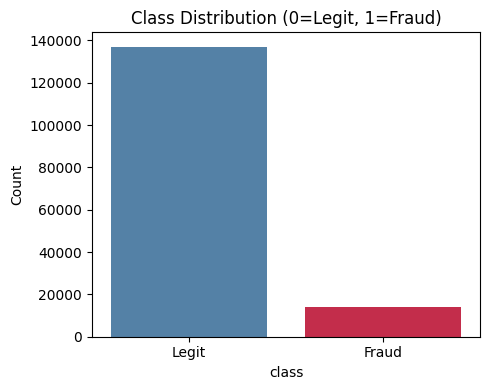

In [5]:
class_counts = fraud['class'].value_counts()
class_pct = fraud['class'].value_counts(normalize=True) * 100

print("=== Class Distribution ===")
print(pd.DataFrame({'count': class_counts, 'percent': class_pct.round(2)}))

# Plot
plt.figure(figsize=(5, 4))
sns.countplot(x='class', data=fraud, palette=['steelblue', 'crimson'])
plt.title('Class Distribution (0=Legit, 1=Fraud)')
plt.xticks([0, 1], ['Legit', 'Fraud'])
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('../data/processed/class_distribution.png', dpi=150)
plt.show()


The dataset is heavily imbalanced: **90.6% legitimate vs 9.4% fraud**. Standard accuracy is misleading here — a model that predicts "legit" every time scores 90.6% while catching zero fraud. We will use AUC-PR and F1 as primary metrics, and apply SMOTE to balance the training set.

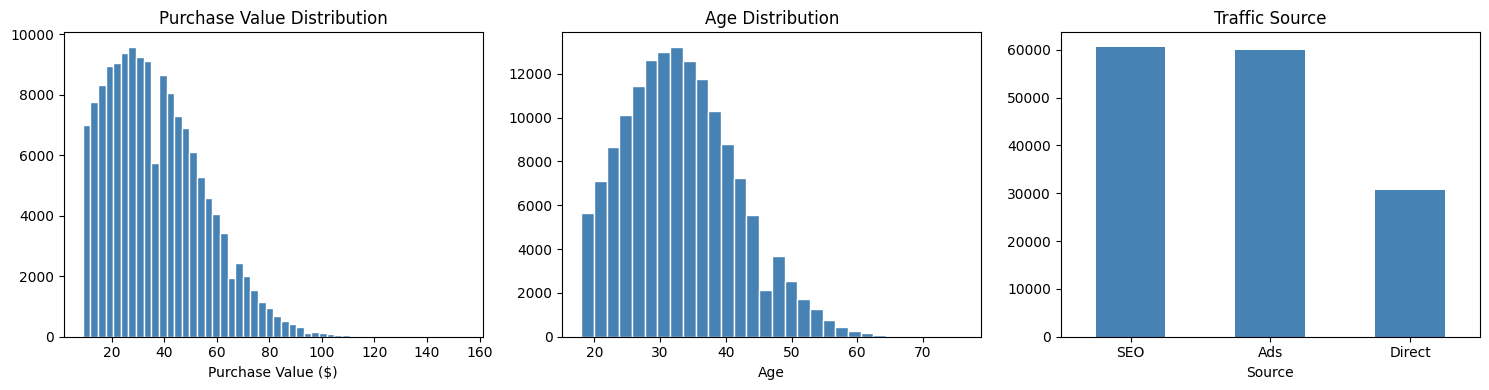

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Purchase value
axes[0].hist(fraud['purchase_value'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Purchase Value Distribution')
axes[0].set_xlabel('Purchase Value ($)')

# Age
axes[1].hist(fraud['age'], bins=30, color='steelblue', edgecolor='white')
axes[1].set_title('Age Distribution')
axes[1].set_xlabel('Age')

# Source
fraud['source'].value_counts().plot(kind='bar', ax=axes[2], color='steelblue')
axes[2].set_title('Traffic Source')
axes[2].set_xlabel('Source')
axes[2].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('../data/processed/univariate.png', dpi=150)
plt.show()


## Univariate Distributions
Purchase values are right-skewed, concentrated between $10–$60. Most users are aged 25–40. Traffic is split roughly evenly between SEO and Ads, with Direct being the smallest channel.

## Fraud Rate by Category

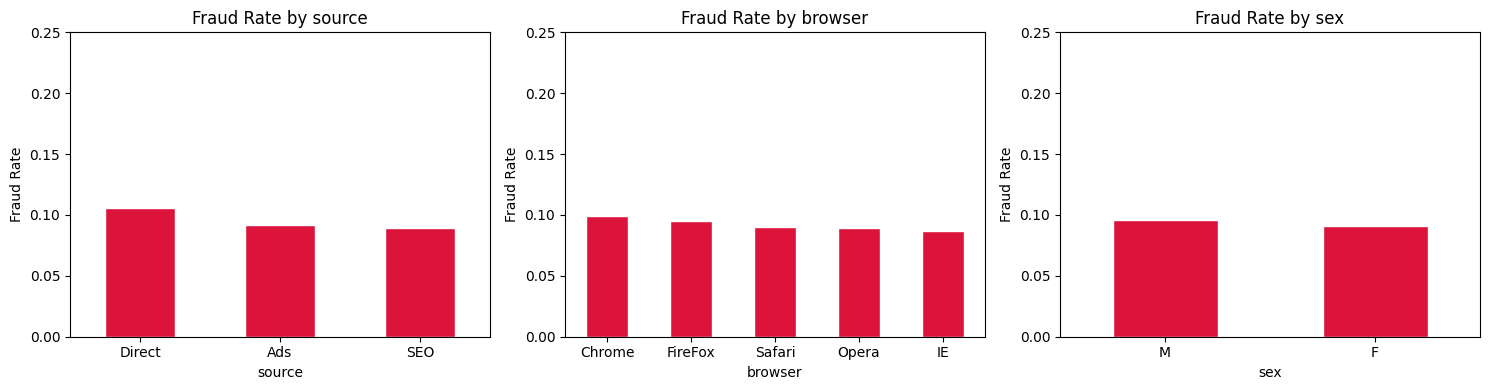

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col in zip(axes, ['source', 'browser', 'sex']):
    fraud_rate = fraud.groupby(col)['class'].mean().sort_values(ascending=False)
    fraud_rate.plot(kind='bar', ax=ax, color='crimson', edgecolor='white')
    ax.set_title(f'Fraud Rate by {col}')
    ax.set_ylabel('Fraud Rate')
    ax.tick_params(axis='x', rotation=0)
    ax.set_ylim(0, 0.25)

plt.tight_layout()
plt.savefig('../data/processed/fraud_rate_categorical.png', dpi=150)
plt.show()


Direct traffic has the highest fraud rate (~10.5%), slightly above Ads and SEO. Browser and sex show almost no difference in fraud rate — these features are unlikely to be strong predictors and may be dropped during modeling.

Feature engineering 

In [8]:
# time_since_signup: how long between signup and purchase (in hours)
fraud['time_since_signup'] = (
    fraud['purchase_time'] - fraud['signup_time']
).dt.total_seconds() / 3600

# Time features
fraud['hour_of_day'] = fraud['purchase_time'].dt.hour
fraud['day_of_week'] = fraud['purchase_time'].dt.dayofweek

# Transaction velocity: how many purchases per user
fraud['user_txn_count'] = fraud.groupby('user_id')['user_id'].transform('count')

# Device velocity: how many users per device (shared device = suspicious)
fraud['device_txn_count'] = fraud.groupby('device_id')['device_id'].transform('count')

print("New features added:")
print(fraud[['time_since_signup', 'hour_of_day', 'day_of_week', 
             'user_txn_count', 'device_txn_count']].describe())

New features added:
       time_since_signup    hour_of_day    day_of_week  user_txn_count  \
count      151112.000000  151112.000000  151112.000000        151112.0   
mean         1370.008125      11.521593       3.011819             1.0   
std           868.406422       6.912474       2.006203             0.0   
min             0.000278       0.000000       0.000000             1.0   
25%           607.431528       6.000000       1.000000             1.0   
50%          1368.429306      12.000000       3.000000             1.0   
75%          2123.479028      17.000000       5.000000             1.0   
max          2879.992222      23.000000       6.000000             1.0   

       device_txn_count  
count     151112.000000  
mean           1.684367  
std            2.616954  
min            1.000000  
25%            1.000000  
50%            1.000000  
75%            1.000000  
max           20.000000  



Four behavioral features added: `time_since_signup` (hours between account creation and purchase), `hour_of_day`, `day_of_week`, and `device_txn_count` (number of users sharing the same device). Every user in this dataset has exactly one transaction (`user_txn_count` = 1), so that feature carries no signal and will be dropped.

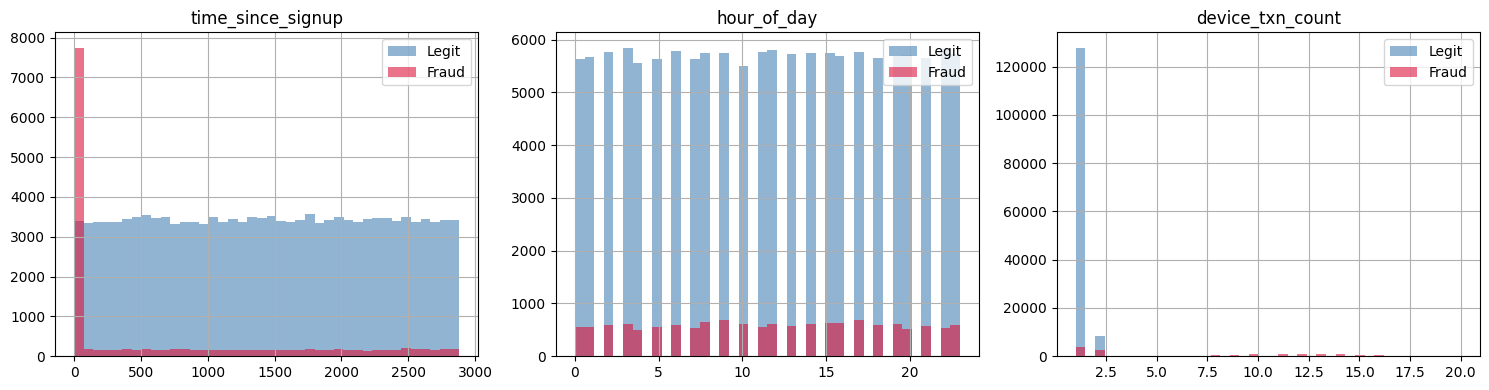

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col in zip(axes, ['time_since_signup', 'hour_of_day', 'device_txn_count']):
    fraud[fraud['class'] == 0][col].hist(bins=40, ax=ax, alpha=0.6, 
                                          label='Legit', color='steelblue')
    fraud[fraud['class'] == 1][col].hist(bins=40, ax=ax, alpha=0.6, 
                                          label='Fraud', color='crimson')
    ax.set_title(col)
    ax.legend()

plt.tight_layout()
plt.savefig('../data/processed/feature_separation.png', dpi=150)
plt.show()


`time_since_signup` is the strongest fraud signal — the massive red spike at zero means most fraud happens within minutes of account creation, while legitimate purchases spread evenly across days. `hour_of_day` shows no separation at all; fraud is distributed uniformly across all hours, making it a weak predictor. `device_txn_count` shows that nearly all transactions (fraud and legit) come from unique devices, but the small fraction of shared devices (count > 2) skews toward fraud.